In [3]:
import rasterio
from rasterio.features import rasterize
from rasterio.enums import MergeAlg
import geopandas as gpd
import numpy as np
import pandas as pd

#Leemos el dataframe

df = pd.read_csv('../DATA/landslides/urban_landslide.csv')
# ------------------------------------------------------------------------------
# 1. CALCULAMOS BINS PARA SLOPE
# ------------------------------------------------------------------------------
# Bins para slope
bins_slope = [0, 10, 35, np.inf]  # np.inf para todo lo que exceda 40
labels_slope = ['0-10', '10-35', '>35']
df['slope_bin'] = pd.cut(df['slope'], bins=bins_slope, labels=labels_slope, right=False)

# ------------------------------------------------------------------------------
# 2. CALCULAMOS BINS PARA ASPECTO
# ------------------------------------------------------------------------------
def categorize_aspect(a):
    """
    Clasifica un valor de 'aspect' en una de las 8 orientaciones:
    N, NE, E, SE, S, SW, W, NW.
    Asume aspecto en rango 0 <= a < 360.
    """
    if a >= 337.5 or a < 22.5:
        return 'N'
    elif 22.5 <= a < 67.5:
        return 'NE'
    elif 67.5 <= a < 112.5:
        return 'E'
    elif 112.5 <= a < 157.5:
        return 'SE'
    elif 157.5 <= a < 202.5:
        return 'S'
    elif 202.5 <= a < 247.5:
        return 'SW'
    elif 247.5 <= a < 292.5:
        return 'W'
    elif 292.5 <= a < 337.5:
        return 'NW'
    else:
        # Por si hay valores raros fuera de rango
        return 'Undefined'
    
df['aspect_bin'] = df['aspect'].apply(categorize_aspect)

# ------------------------------------------------------------------------------
# 3. CALCULAMOS BINS PARA ALTURAS
# ------------------------------------------------------------------------------
bins_elev = [1500, 2000, 2500, np.inf]
labels_elev = ['1.500 - 2.000', '2.000 - 2.500', '> 2.500']

df['elev_bin'] = pd.cut(df['elev'], bins=bins_elev, labels=labels_elev, right=False)

# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 4. CALCULAR LA FRECUENCIA (RATIO) DE DESLIZAMIENTOS EN CADA BIN
# ------------------------------------------------------------------------------

# ------------------------------------------------------------------------------
# FRECUENCIA DE DESLIZAMIENTOS POR CATEGORÍA DE SLOPE
# ------------------------------------------------------------------------------
# Total global
total_pixels_urban   = df[df['urban'] == 1].shape[0]
total_pixels_rural   = df[df['urban'] == 0].shape[0]
total_lands_urban    = df[(df['urban'] == 1) & (df['landslide'] == 1)].shape[0]
total_lands_rural    = df[(df['urban'] == 0) & (df['landslide'] == 1)].shape[0]

# Agrupar por urban y slope_bin
bin_counts_slope = df.groupby(['urban', 'slope_bin']).size().reset_index(name='total_pixels')
landslide_counts_slope = df[df['landslide'] == 1].groupby(['urban', 'slope_bin']).size().reset_index(name='landslide_count')

# Unir
merged_slope = pd.merge(bin_counts_slope, landslide_counts_slope,
                        on=['urban', 'slope_bin'], how='left')
merged_slope['landslide_count'] = merged_slope['landslide_count'].fillna(0)

# Añadir proporciones
def compute_fr(row):
    if row['urban'] == 1:
        prop_area = (row['total_pixels'] / total_pixels_urban)*100
        prop_lands = (row['landslide_count'] / total_lands_urban)*100 if total_lands_urban > 0 else 0
    else:
        prop_area = (row['total_pixels'] / total_pixels_rural)*100
        prop_lands = (row['landslide_count'] / total_lands_rural)*100 if total_lands_rural > 0 else 0

    return prop_lands / prop_area if prop_area > 0 else 0

merged_slope['frequency_ratio'] = merged_slope.apply(compute_fr, axis=1)

# ------------------------------------------------------------------------------
# FRECUENCIA DE DESLIZAMIENTOS POR CATEGORÍA DE ASPECT
# ------------------------------------------------------------------------------
# Aspect
total_lands_urban    = df[(df['urban'] == 1) & (df['landslide'] == 1)].shape[0]
total_lands_rural    = df[(df['urban'] == 0) & (df['landslide'] == 1)].shape[0]

bin_counts_aspect = df.groupby(['urban', 'aspect_bin']).size().reset_index(name='total_pixels')
landslide_counts_aspect = df[df['landslide'] == 1].groupby(['urban', 'aspect_bin']).size().reset_index(name='landslide_count')

# Unir
merged_aspect = pd.merge(bin_counts_aspect, landslide_counts_aspect,
                        on=['urban', 'aspect_bin'], how='left')

merged_aspect['landslide_count'] = merged_aspect['landslide_count'].fillna(0)

# Añadir proporciones
def compute_fr(row):
    if row['urban'] == 1:
        prop_area = (row['total_pixels'] / total_pixels_urban)*100
        prop_lands = (row['landslide_count'] / total_lands_urban)*100 if total_lands_urban > 0 else 0
    else:
        prop_area = (row['total_pixels'] / total_pixels_rural)*100
        prop_lands = (row['landslide_count'] / total_lands_rural)*100 if total_lands_rural > 0 else 0

    return prop_lands / prop_area if prop_area > 0 else 0

merged_aspect['frequency_ratio'] = merged_aspect.apply(compute_fr, axis=1)


# ------------------------------------------------------------------------------
# FRECUENCIA DE DESLIZAMIENTOS POR CATEGORÍA DE ALTITUD
# ------------------------------------------------------------------------------
# Elevation
bin_counts_elev = df.groupby(['urban', 'elev_bin']).size().reset_index(name='total_pixels')
landslide_counts_elev = df[df['landslide'] == 1].groupby(['urban', 'elev_bin']).size().reset_index(name='landslide_count')

# Unir
merged_elev = pd.merge(bin_counts_elev, landslide_counts_elev,
                        on=['urban', 'elev_bin'], how='left')
merged_elev['landslide_count'] = merged_elev['landslide_count'].fillna(0)
# Añadir proporciones
def compute_fr(row):
    if row['urban'] == 1:
        prop_area = (row['total_pixels'] / total_pixels_urban)*100
        prop_lands = (row['landslide_count'] / total_lands_urban)*100 if total_lands_urban > 0 else 0
    else:
        prop_area = (row['total_pixels'] / total_pixels_rural)*100
        prop_lands = (row['landslide_count'] / total_lands_rural)*100 if total_lands_rural > 0 else 0

    return prop_lands / prop_area if prop_area > 0 else 0

merged_elev['frequency_ratio'] = merged_elev.apply(compute_fr, axis=1)

FileNotFoundError: [Errno 2] No such file or directory: '../DATA/landslides/urban_landslide.csv'

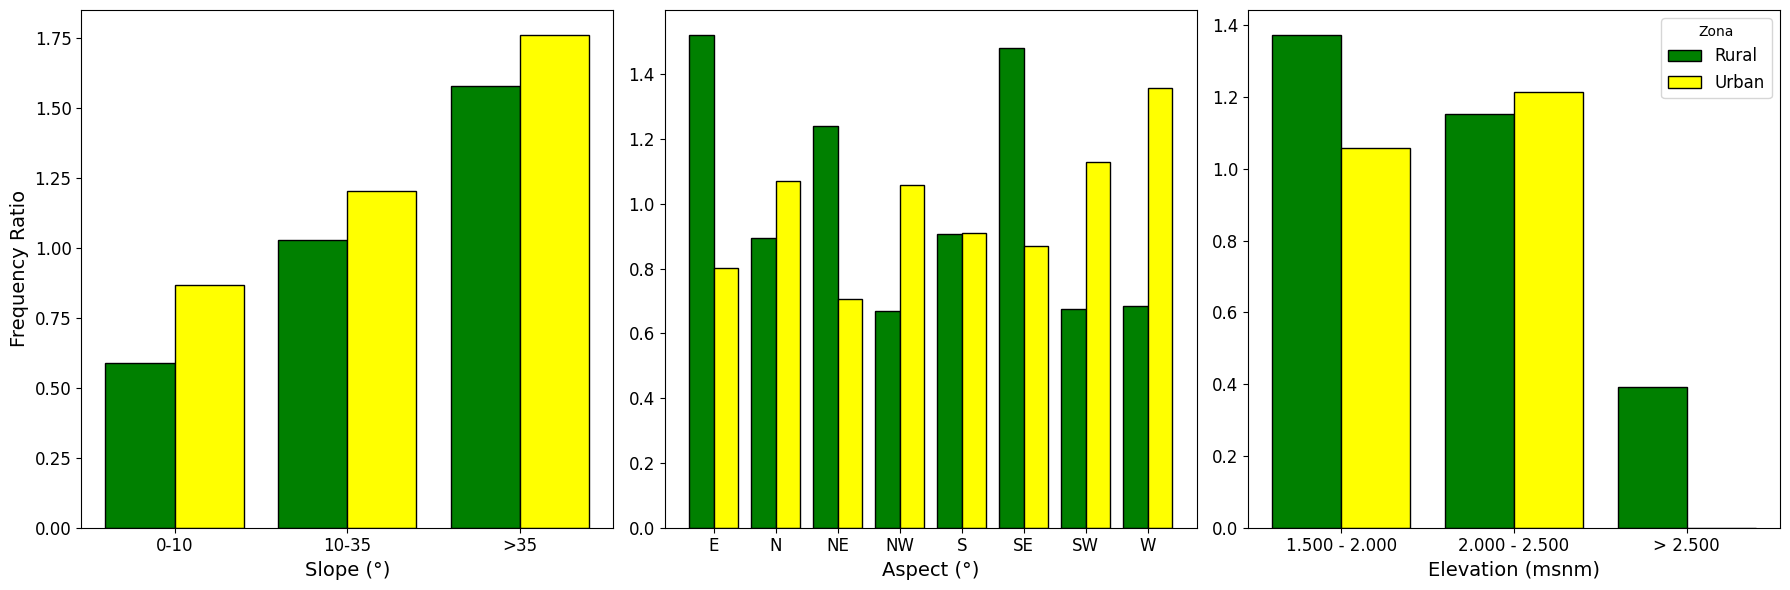

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_frequency_ratio_subplots(
    dfs,                # Lista de dataframes: [df1, df2, df3]
    category_cols,      # Lista de nombres de columnas para cada eje X
    category_names,     # Lista de nombres para etiquetas de cada eje X
    freq_col='frequency_ratio',
    urban_col='urban',
    titles=None         # Títulos para cada subplot
):
    """
    Genera un gráfico con 3 subplots de barras agrupadas para comparar Rural vs Urban en distintas variables.
    """

    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))
    palette = {'Urban': 'yellow', 'Rural': 'green'}
    width = 0.4

    for i, ax in enumerate(axes):
        df = dfs[i]
        category_col = category_cols[i]
        category_name = category_names[i]
        title = titles[i] if titles else f'Frequency Ratio by {category_name}'

        # Pivotear los datos
        pivot_df = df.pivot(index=category_col, columns=urban_col, values=freq_col)

        # Asegurar columnas para ambos valores de urban
        if 0 not in pivot_df.columns:
            pivot_df[0] = 0
        if 1 not in pivot_df.columns:
            pivot_df[1] = 0

        # Preparar coordenadas X y valores
        x_labels = pivot_df.index.astype(str)
        X = np.arange(len(x_labels))
        rural_values = pivot_df[0].values
        urban_values = pivot_df[1].values

        # Dibujar barras
        ax.bar(X - width/2, rural_values, width=width, label='Rural', color=palette['Rural'], edgecolor='black')
        ax.bar(X + width/2, urban_values, width=width, label='Urban', color=palette['Urban'], edgecolor='black')

        # Ejes y etiquetas
        ax.set_xticks(X)
        ax.set_xticklabels(x_labels, rotation=0)
        ax.set_xlabel(category_name, fontsize=14)
        if i == 0:
            ax.set_ylabel('Frequency Ratio', fontsize=14)
        #ax.set_ylabel('Frequency Ratio', fontsize=14)
        #ax.set_title(title, fontsize=16)

        # Estética
        ax.tick_params(axis='x', labelsize=12)
        ax.tick_params(axis='y', labelsize=12)
        ax.spines['top'].set_visible(True)
        ax.spines['right'].set_visible(True)
        ax.grid(False)

    # Solo un recuadro de leyenda
    axes[2].legend(title='Zona', loc='upper right', fontsize=12)

    plt.tight_layout()
    plt.savefig('../../FIGURES/freq_ratio_urban_rural.png', dpi=500, bbox_inches='tight')
    plt.show()

# Ejecutar función con tus tres dataframes
plot_frequency_ratio_subplots(
    dfs=[merged_slope, merged_aspect, merged_elev],
    category_cols=['slope_bin', 'aspect_bin', 'elev_bin'],
    category_names=['Slope (°)', 'Aspect (°)', 'Elevation (msnm)'],
    titles=['Slope', 'Aspect', 'Elevation']
)
